<a href="https://colab.research.google.com/github/hems456/Spider-ML-Task-1/blob/main/spml_basetask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPIDER ML TASK 1 - BASE TASK
# Fashion MNIST Classification using PyTorch

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import pickle

# Device Configuration

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# Load Dataset

In [ ]:
transform = transforms.ToTensor()

dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Train Samples:", len(train_dataset))
print("Validation Samples:", len(val_dataset))
print("Test Samples:", len(test_dataset))

# Neural Network Architecture

In [ ]:
class FashionNet(nn.Module):

    def __init__(self):
        super(FashionNet, self).__init__()

        self.fc1 = nn.Linear(784, 16)

        # Left Branch
        self.left1 = nn.Linear(16, 8)
        self.left2 = nn.Linear(8, 8)

        # Right Branch
        self.right1 = nn.Linear(16, 12)
        self.right2 = nn.Linear(12, 8)

        # Output Layer
        self.output = nn.Linear(16, 10)

    def forward(self, x):

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))

        # LEFT BRANCH
        l1 = F.relu(self.left1(x))
        l2 = F.relu(self.left2(l1))

        skip_connection = l1 + l2

        # RIGHT BRANCH
        r1 = F.relu(self.right1(x))
        r2 = F.relu(self.right2(r1))

        # CONCATENATION
        merged = torch.cat((skip_connection, r2), dim=1)

        output = self.output(merged)

        return output


model = FashionNet().to(device)

print(model)

# Loss and Optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# Training

In [ ]:
epochs = 15

train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(epochs):

    # TRAINING
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # VALIDATION

    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.2f}%"
    )

# Plot Loss Graph

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

# Plot Accuracy Graph

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

# Save Model Weights using Pickle

In [ ]:
with open("fashion_model.pkl", "wb") as file:
    pickle.dump(model.state_dict(), file)

print("Model Saved Successfully!")

# Generate Predictions

In [ ]:
predictions = []

model.eval()

with torch.no_grad():

    for images, _ in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        predictions.extend(predicted.cpu().numpy())

# Create submission.csv

In [ ]:
import pandas as pd

submission = pd.DataFrame({
    "Id": range(len(predictions)),
    "Label": predictions
})

submission.to_csv(
    "submission.csv",
    index=False
)

print("submission.csv Generated!")

print(submission.head())

Using Device: cpu


100%|██████████| 26.4M/26.4M [00:01<00:00, 17.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 273kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.02MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.1MB/s]


Train Samples: 48000
Validation Samples: 12000
Test Samples: 10000
FashionNet(
  (fc1): Linear(in_features=784, out_features=16, bias=True)
  (left1): Linear(in_features=16, out_features=8, bias=True)
  (left2): Linear(in_features=8, out_features=8, bias=True)
  (right1): Linear(in_features=16, out_features=12, bias=True)
  (right2): Linear(in_features=12, out_features=8, bias=True)
  (output): Linear(in_features=16, out_features=10, bias=True)
)
Epoch [1/15] Train Loss: 0.8089 Train Acc: 71.05% Val Loss: 0.5595 Val Acc: 80.21%
Epoch [2/15] Train Loss: 0.5108 Train Acc: 82.06% Val Loss: 0.5035 Val Acc: 82.06%
Epoch [3/15] Train Loss: 0.4602 Train Acc: 83.95% Val Loss: 0.4560 Val Acc: 84.36%
Epoch [4/15] Train Loss: 0.4333 Train Acc: 84.80% Val Loss: 0.4373 Val Acc: 84.89%
Epoch [5/15] Train Loss: 0.4115 Train Acc: 85.59% Val Loss: 0.4247 Val Acc: 85.42%
Epoch [6/15] Train Loss: 0.3984 Train Acc: 85.98% Val Loss: 0.4132 Val Acc: 85.67%
Epoch [7/15] Train Loss: 0.3864 Train Acc: 86.41% V

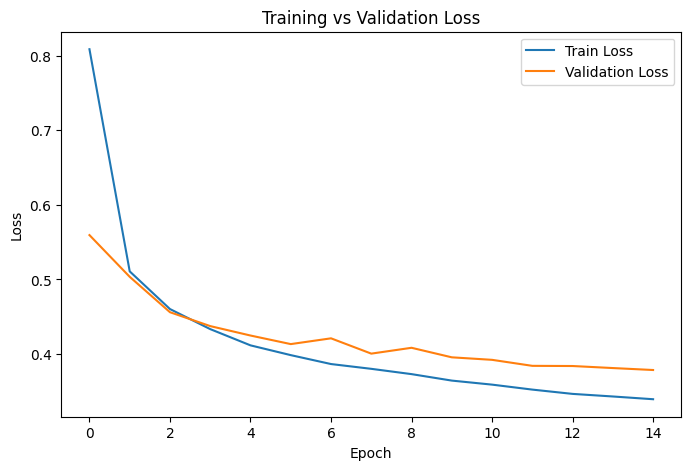

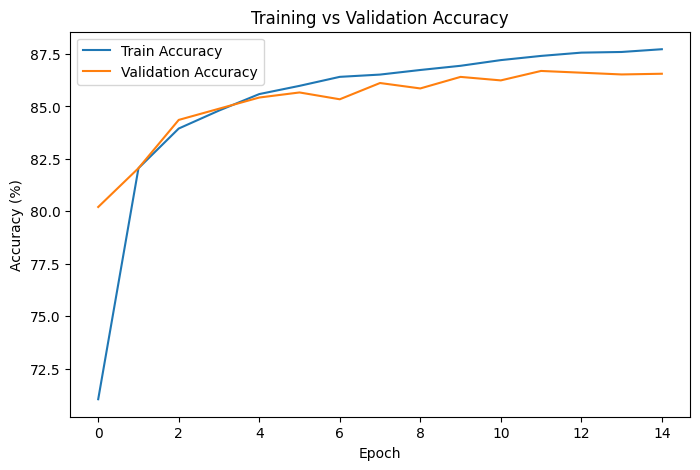

Model Saved Successfully!
submission.csv Generated!
   Id  Label
0   0      9
1   1      2
2   2      1
3   3      1
4   4      6
